# Evaluate conditions (between statements)
- LOG: TH500
- K: 5


In [1]:
%load_ext autoreload
%autoreload 2

from sdss_eval.evaluator import run_n_tests, create_tests
from sdss_eval.sqlparser import schema

                Test  MAP@K  Execution Time
1                UCB   0.78            0.13
3  Thompson Sampling   0.75            0.15
4       Most popular   0.73            0.51
2               pUCB   0.72            0.14
0            Egreedy   0.71            0.12
                Test  MAP@K  Execution Time
1                UCB   0.81            0.10
2               pUCB   0.79            0.11
3  Thompson Sampling   0.78            0.12
4       Most popular   0.78            0.39
0            Egreedy   0.75            0.09
                Test  MAP@K  Execution Time
2               pUCB   0.78            0.13
1                UCB   0.77            0.12
3  Thompson Sampling   0.74            0.14
0            Egreedy   0.71            0.11
4       Most popular   0.66            0.48


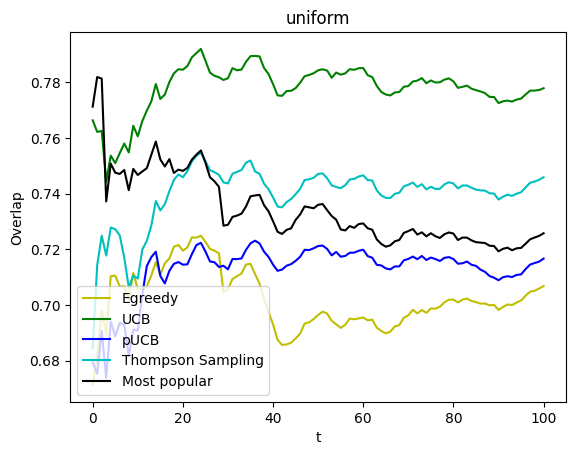

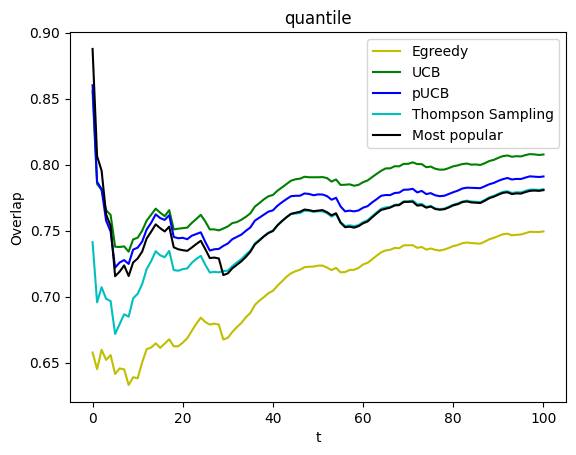

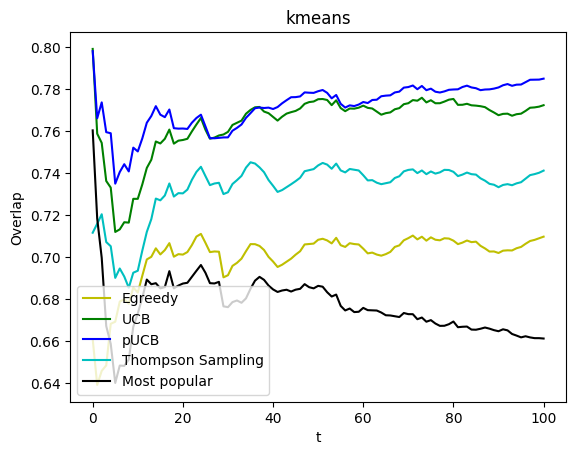

In [2]:
cols = [
            "specobj.z",
            "specobj.ra",
            "specobj.dec",
            "photoobj.ra",
            "photoobj.g" ,
            "photoobj.u"          
]
for binning_method in ["uniform", "quantile", "kmeans"]:
    db = schema()
    db.create_bins(discretization_method=binning_method, columns=cols)
    tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb","popularRegion"], clause=3, top_k = 5 , db = db , th = 500 )
    print(run_n_tests(tests, binning_method, ylabel = "Overlap").results)